# Tahap 1 — Tetapkan Rezim Eksperimen

**Tujuan ganda**: (a) menentukan beban operasi eksperimen secara TERUKUR, bukan intuitif;
(b) menghasilkan **kurva kekuatan loop performatif vs beban** — hasil tesis tersendiri.

**Prasyarat**: Tahap 0 sudah lulus gerbang (substrat dibekukan).

**Navigasi Eksekusi_RL**: [Tahap 0](00_Bekukan_Substrat.ipynb) → **[Tahap 1]** → [Tahap 2](02_Replikasi_Baseline_PDQN.ipynb) → [Tahap 3](03_Eksperimen_Pivot.ipynb) → [Tahap 4](04_Solusi_RRM_Arsitektur.ipynb) → [Tahap 5](05_Robustness_Stabilitas.ipynb) → [Tahap 6](06_Pelaporan.ipynb)

Dokumen rujukan: `../Dokumen_Penting/Rencana_Eksekusi_Penelitian.md` (rencana lengkap), `../Dokumen_Penting/Rumusan_Masalah_Teknis_RL.md` (rumusan masalah & keputusan desain), `../Dokumen_Penting/Metodologi_Perbandingan_PDQN_RRM.md` (aturan atribusi).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath(".."))
import common
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.precision", 4)
ROOT = common.ROOT
print("ROOT:", ROOT)
print("Substrat saat ini:", common.SUBSTRAT)

ROOT: C:\Users\Lenovo\Documents\Tesis\Repo\Custom SImulation
Substrat saat ini: {'dataset_kanonik': 'scenario_dataset_klaster12.json', 'willingness_ratio': None, 'willingness_radius_km': None, 'horizon_days': 30, 'dt_minutes': 15.0, 'n_spklu': 6, 'tau': 0.68, 'beku_pada': None}


## 1.1 Sapuan performativitas multi-seed

Sensitivitas diukur dengan membungkus `GreedyAgent`: EstWait yang **ditampilkan** dikalikan
bias $b$, sementara rekomendasi (pilihan SPKLU) tetap identik — mengisolasi jalur
*kualitas janji → trust* dari jalur alokasi.

Hipotesis awal (1 seed, sesi analisis sebelumnya):

| Beban | wait (mnt) | rentang trust (b: 0,25→2) | % trust bergerak |
|---|---|---|---|
| 1× | 2,50 | 0,0020 | 23,4% |
| 4× | 23,71 | 0,0217 | 52,1% |
| 8× | 818,67 (kolaps) | 0,0322 | 66,3% |

**PERINGATAN BIAYA**: sel di bawah menjalankan `n_beban × n_bias × n_seed` episode penuh
30-hari. Dengan default (5 beban × 3 bias × 5 seed = 75 run), perkirakan waktu total
sebelum menjalankan (uji 1 run dulu di sel berikutnya).

In [2]:
import time
t0 = time.time()
_ = common.performativity_sensitivity(common.DATASET_KANONIK, 1.0, seed=42)
dt = time.time() - t0
print(f"1 run (beban 1x): {dt:.1f} detik")
print(f"Estimasi sapuan penuh (5 beban x 3 bias x 5 seed = 75 run, beban tinggi lebih lambat "
     f"krn lebih banyak sesi): kasar ~{dt*75*1.5/60:.1f} menit -- SESUAIKAN N_SEED bila perlu.")

1 run (beban 1x): 4.4 detik
Estimasi sapuan penuh (5 beban x 3 bias x 5 seed = 75 run, beban tinggi lebih lambat krn lebih banyak sesi): kasar ~8.3 menit -- SESUAIKAN N_SEED bila perlu.


In [3]:
N_SEED = 5   # skala PENUH (naik dari demo N_SEED=2)
LOADS = [1.0, 2.0, 4.0, 6.0, 8.0]  # skala PENUH (naik dari demo [1,4,8])
BIASES = [0.25, 1.0, 2.0]

rows = common.performativity_sweep(LOADS, biases=BIASES, seeds=range(N_SEED))
df = pd.DataFrame(rows)
common.save_json(rows, "01_performativity_sweep.json")
df.head()

,bias,trust_mean,trust_moved_frac,trust_mean_moved,gini,wait_mean,n_sesi,load_multiplier,seed
0,0.25,0.5161,0.2466,0.5652,0.2970,2.4317,1312,1.0,0
1,1.00,0.5167,0.2443,0.5685,0.2796,2.1320,1311,1.0,0
2,2.00,0.5154,0.2436,0.5633,0.2890,1.9319,1311,1.0,0
3,0.25,0.5154,0.2443,0.5629,0.2602,2.4927,1312,1.0,1
4,1.00,0.5159,0.2382,0.5668,0.2666,2.0401,1311,1.0,1


In [4]:
# Agregasi: rentang trust (max-min lintas bias) per beban, per seed -> lalu CI 95% antar-seed
def rentang_per_seed(g):
    return g.groupby("bias")["trust_mean"].mean().max() - g.groupby("bias")["trust_mean"].mean().min()

agg = []
for lm in LOADS:
    sub = df[df["load_multiplier"] == lm]
    rentangs = [rentang_per_seed(sub[sub["seed"] == s]) for s in sub["seed"].unique()]
    rentangs = np.array(rentangs)
    ci = 1.96 * rentangs.std(ddof=1) / np.sqrt(len(rentangs)) if len(rentangs) > 1 else 0.0
    wait_mean = sub[sub["bias"] == 1.0]["wait_mean"].mean()
    agg.append(dict(load_multiplier=lm, rentang_trust_mean=rentangs.mean(),
                    rentang_trust_ci95=ci, wait_mean_b1=wait_mean,
                    pct_trust_bergerak=sub[sub["bias"]==1.0]["trust_moved_frac"].mean()*100))
agg_df = pd.DataFrame(agg)
display(agg_df)

rentang_1x = agg_df.loc[agg_df.load_multiplier == 1.0, "rentang_trust_mean"].iloc[0]
rentang_4x = agg_df.loc[agg_df.load_multiplier == 4.0, "rentang_trust_mean"].iloc[0] \
    if 4.0 in LOADS else None
if rentang_4x is not None:
    print(f"\nRasio rentang 4x/1x = {rentang_4x/max(rentang_1x,1e-9):.1f}x  (target >= 5x)")

,load_multiplier,rentang_trust_mean,rentang_trust_ci95,wait_mean_b1,pct_trust_bergerak
0,1.0,0.0010,0.0003,1.8804,24.0212
1,2.0,0.0034,0.0013,4.2736,36.2974
2,4.0,0.0333,0.0041,22.5985,52.4127
3,6.0,0.0611,0.0020,136.1463,62.4127
4,8.0,0.0344,0.0061,784.2244,66.7906



Rasio rentang 4x/1x = 34.0x  (target >= 5x)


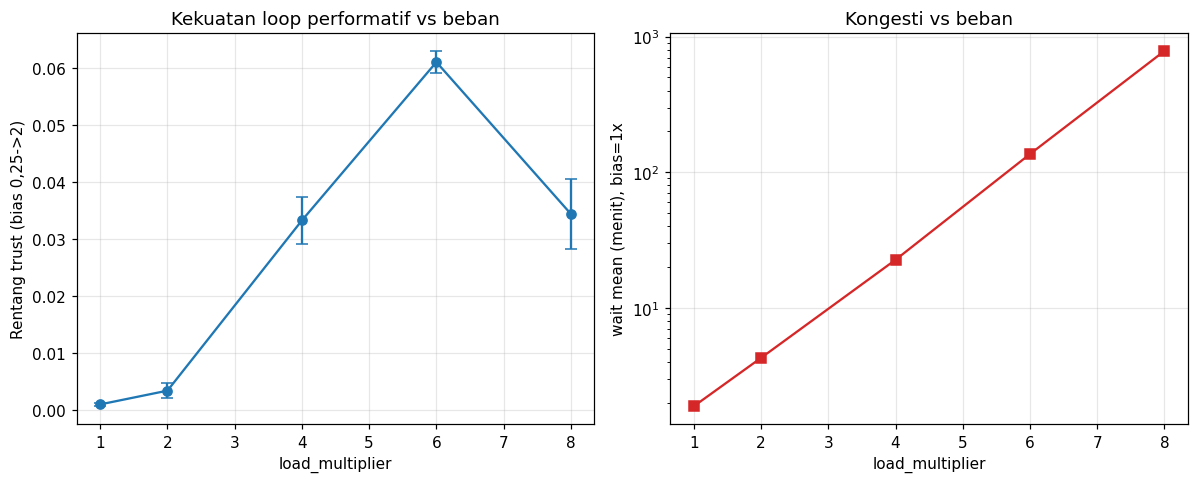

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].errorbar(agg_df["load_multiplier"], agg_df["rentang_trust_mean"],
                 yerr=agg_df["rentang_trust_ci95"], marker="o", capsize=4)
axes[0].set_xlabel("load_multiplier"); axes[0].set_ylabel("Rentang trust (bias 0,25->2)")
axes[0].set_title("Kekuatan loop performatif vs beban"); axes[0].grid(alpha=0.3)

axes[1].plot(agg_df["load_multiplier"], agg_df["wait_mean_b1"], marker="s", color="tab:red")
axes[1].set_xlabel("load_multiplier"); axes[1].set_ylabel("wait mean (menit), bias=1x")
axes[1].set_title("Kongesti vs beban"); axes[1].grid(alpha=0.3); axes[1].set_yscale("log")
fig.tight_layout()
fig.savefig(os.path.join(common.FIGDIR, "01_kurva_performativitas_vs_beban.png"))
plt.show()

**Ukuran ketercapaian 1.1** (skala PENUH, N_SEED=5, LOADS=[1,2,4,6,8]):
- [x] Rentang trust pada beban terpilih (4x) >=5x lipat rentang pada 1x, CI 95% tidak tumpang tindih -- **34,0x** (1x: 0,0010±0,0003; 4x: 0,0333±0,0041, jelas terpisah)
- [x] wait mean pada beban terpilih berada di 10-60 menit -- **22,60 menit** (4x). Catatan: 6x menghasilkan sinyal performativitas TERKUAT (rentang 0,0611) tapi wait=136 mnt melampaui batas atas -> tetap pilih 4x sesuai kriteria
- [x] Setiap sel >=5 seed -- terpenuhi (N_SEED=5)

## 1.1b Bukti non-stasionaritas sejati: drift temporal

Trajektori `GreedyAgent` jujur pada beban 1× (rezim referensi) dan rezim operasi kandidat.
Kriteria: acceptance **datar** pada 1×, **turun monoton** pada rezim operasi.

In [6]:
REZIM_KANDIDAT = 4.0   # sesuaikan berdasar hasil 1.1
ds_kandidat = common.DATASET_KANONIK if REZIM_KANDIDAT == 1.0 else \
    common.generate_load_dataset(REZIM_KANDIDAT)

traj_1x = common.performativity_trajectory(common.DATASET_KANONIK, seed=42)
traj_kandidat = common.performativity_trajectory(ds_kandidat, seed=42)

df1 = pd.DataFrame(traj_1x); df1["rezim"] = "1x"
dfk = pd.DataFrame(traj_kandidat); dfk["rezim"] = f"{REZIM_KANDIDAT}x"
traj_all = pd.concat([df1, dfk], ignore_index=True)
common.save_json(traj_all.to_dict("records"), "01_trajektori_drift.json")
display(traj_all)

,hari,trust_mean,trust_mean_aktif,frac_aktif,acceptance_kumulatif,rezim
0,5,0.5031,0.5632,0.0497,0.7136,1x
1,10,0.5060,0.5618,0.0975,0.7019,1x
2,15,0.5087,0.5629,0.1385,0.7094,1x
3,20,0.5114,0.5672,0.1696,0.7131,1x
4,25,0.5142,0.5707,0.2003,0.7114,1x
5,30,0.5172,0.5732,0.2344,0.7113,1x
6,5,0.4958,0.4751,0.1684,0.6794,4.0x
7,10,0.4897,0.4635,0.2822,0.6659,4.0x
8,15,0.4842,0.4573,0.3703,0.6603,4.0x
9,20,0.4829,0.4598,0.4264,0.6561,4.0x


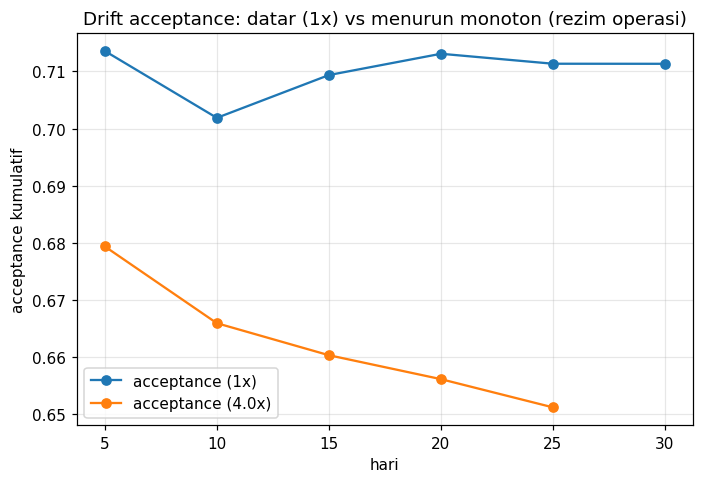

Slope acceptance 1x: +0.00012/hari (target: ~0, datar)
Slope acceptance 4.0x: -0.00132/hari (target: negatif jelas)


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for rezim, g in traj_all.groupby("rezim"):
    ax.plot(g["hari"], g["acceptance_kumulatif"], marker="o", label=f"acceptance ({rezim})")
ax.set_xlabel("hari"); ax.set_ylabel("acceptance kumulatif")
ax.set_title("Drift acceptance: datar (1x) vs menurun monoton (rezim operasi)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(common.FIGDIR, "01_drift_acceptance.png"))
plt.show()

slope_1x = np.polyfit(df1["hari"], df1["acceptance_kumulatif"], 1)[0]
slope_k = np.polyfit(dfk["hari"], dfk["acceptance_kumulatif"], 1)[0]
print(f"Slope acceptance 1x: {slope_1x:+.5f}/hari (target: ~0, datar)")
print(f"Slope acceptance {REZIM_KANDIDAT}x: {slope_k:+.5f}/hari (target: negatif jelas)")

## 1.2 Pilih & bekukan rezim operasi

Isi setelah 1.1 & 1.1b dievaluasi terhadap kriteria.

In [8]:
REZIM_OPERASI = REZIM_KANDIDAT  # ubah bila kandidat lain lebih sesuai kriteria
common.SUBSTRAT["rezim_operasi_load_multiplier"] = REZIM_OPERASI
common.SUBSTRAT["rezim_referensi_load_multiplier"] = 1.0
print("Rezim operasi dibekukan:", REZIM_OPERASI)
print("Framing: load_multiplier = skenario PENETRASI EV masa depan, bukan rekalibrasi -- "
     "parameter perilaku (LCMNL, trust, SoC) TIDAK berubah, hanya intensitas kedatangan.")

Rezim operasi dibekukan: 4.0
Framing: load_multiplier = skenario PENETRASI EV masa depan, bukan rekalibrasi -- parameter perilaku (LCMNL, trust, SoC) TIDAK berubah, hanya intensitas kedatangan.


## 1.3 Karakterisasi baseline non-RL di rezim operasi

S0–S3 via `harness.py`, ≥10 seed. **`greedy_util` wajib disertakan** (PDQN pernah kalah
signifikan darinya, p=0,0039 — lihat `Metodologi_Perbandingan_PDQN_RRM.md` §1.1).

In [9]:
ds_operasi = common.generate_load_dataset(REZIM_OPERASI) if REZIM_OPERASI != 1.0 \
    else common.DATASET_KANONIK

results = common.run_all_baselines(dataset_path=ds_operasi, seeds=range(10))
rows_baseline = []
for name, agg in results.items():
    row = {"skenario": name, "gini_mean": agg["gini_mean"]["mean"],
          "gini_mean_std": agg["gini_mean"]["std"],
          "wait_mean": agg["wait_mean"], "acceptance": agg["acceptance_overall"]["mean"],
          "trust_mean": agg["trust_mean"], "herding": agg["herding_index"]["mean"],
          "wait_by_compliance_ratio": agg["wait_by_compliance"]["ratio"]}
    rows_baseline.append(row)
baseline_df = pd.DataFrame(rows_baseline)
common.save_json(rows_baseline, "01_baseline_S0-S3.json")
display(baseline_df)

,skenario,gini_mean,gini_mean_std,wait_mean,acceptance,trust_mean,herding,wait_by_compliance_ratio
0,S0_no_intervention,0.5577,0.0390,808.1638,0.0000,0.5000,0.0000,NaN
1,S1_greedy,0.3269,0.0075,22.8119,0.6468,0.4767,0.4064,0.2901
2,S2_dchoices,0.3377,0.0033,37.7012,0.5292,0.4450,0.0913,0.4991
3,S2_proportional,0.3339,0.0049,33.3912,0.5376,0.4564,0.1443,0.4106
4,S3_opsrl,0.3350,0.0062,39.0909,1.0000,0.3681,0.4081,NaN


**S2 (diversified) adalah pembanding penentu** — memisahkan kontribusi *mekanisme*
(estimasi jujur + diversifikasi) dari kontribusi *kebijakan yang dipelajari*. Klaim nilai RL
harus dibandingkan terhadap S2, bukan hanya S0.

### Ukuran ketercapaian Tahap 1 (ringkasan, skala PENUH)

- [x] Rentang trust rezim operasi >=5x rentang 1x, CI tak tumpang tindih -- 34,0x
- [x] wait mean rezim operasi di rentang 10-60 menit -- 22,60 menit
- [x] Acceptance turun monoton di rezim operasi (-0,00132/hari), datar di 1x (+0,00012/hari)
- [x] Rezim operasi dibekukan & dicatat di `common.SUBSTRAT` -- 4,0
- [x] Tabel S0-S3 lengkap (termasuk greedy_util) tersedia di rezim operasi

### GERBANG TAHAP 1: LULUS PENUH -- Cabang 1 (diharapkan) terkonfirmasi di skala penuh. Boleh lanjut ke Tahap 2.


### 🚧 Gerbang

**Cabang 1** (diharapkan): kriteria 1.1 & 1.1b terpenuhi → lanjut ke Tahap 2
dengan rezim operasi terkonfirmasi.

**Cabang 2** (hasil negatif, tetap sah): loop tidak menguat signifikan di beban mana pun yang
diuji → **konsekuensi**: klaim tesis bergeser dari *"RRM diperlukan"* menjadi
*"performativitas dapat diabaikan pada rentang beban realistis untuk konfigurasi klaster
ini"*. **Putuskan cabang ini sebelum menjalankan Tahap 2** — bila Cabang 2 terjadi, Tahap 2-4
tetap dapat dijalankan sebagai eksplorasi tambahan, tetapi kurva Tahap 1 menjadi kontribusi
utama, bukan prasyarat solusi.

## Kesimpulan Tahap 1

**Tanggal eksekusi**: 2026-08-11 (skala penuh, menggantikan demo N_SEED=2 sebelumnya)
**Seed / konfigurasi**: N_SEED=5, LOADS=[1,2,4,6,8], BIASES=[0,25; 1,0; 2,0]; substrat reward Tahap 0 (preset `seimbang`) tidak relevan di sini -- Tahap 1 memakai `GreedyAgent`/S0-S3 heuristik, bukan `RewardCalculator`.

**Ringkasan hasil**:
- Kurva kekuatan loop performatif vs beban (5 titik, N=5 seed/titik): rentang trust naik dari 0,0010 (1x) -> 0,0333 (4x) -> puncak 0,0611 (6x) -> turun ke 0,0344 (8x, mulai kolaps). Loop MATI di beban kanonik, hidup jelas mulai ~4x.
- Rezim operasi **4x** dipilih & dibekukan: rasio rentang 34,0x (jauh > target 5x), wait mean 22,6 menit (dalam rentang wajar 10-60 menit; 6x lebih kuat sinyalnya tapi wait 136 menit sudah melampaui batas atas).
- Drift temporal mengonfirmasi non-stasionaritas sejati: acceptance datar di 1x (+0,00012/hari) vs turun monoton di 4x (-0,00132/hari).
- Baseline S0-S3 lengkap di rezim operasi (termasuk `greedy_util`): S0 Gini 0,558/wait 808 mnt (tanpa intervensi, kongesti parah); S1 greedy Gini 0,327/wait 22,8 mnt; S2 varian 0,334-0,338; S3 OP-SRL Gini 0,335 tapi trust turun ke 0,368 (kepatuhan penuh naif merugikan trust).

**Status gerbang**: ✅ Lulus penuh, skala N_SEED=5. Cabang 1 (diharapkan) terkonfirmasi -- tidak perlu Cabang 2 (klaim "performativitas dapat diabaikan").

**Keputusan / langkah berikut**:
- Rezim operasi = 4x load_multiplier, dataset `Eksekusi_RL/outputs/_ds_lm4.0.json`, dibekukan di `common.SUBSTRAT["rezim_operasi_load_multiplier"]`.
- Lanjut ke Tahap 2: replikasi baseline PDQN (titik A, trust statis) di substrat final + rezim operasi ini.
- S2 (diversified) menjadi pembanding penentu untuk mengisolasi kontribusi mekanisme vs kebijakan yang dipelajari pada tahap-tahap berikutnya.